## Project Overview

> **Chips Sales Performance Analysis.**

> A fast food outlet want to understand customer purchasing behavior and product performance across its chips market. The business has transcation-level sales data that can be used to identify the most valuable customer segment, understand product performance, and track changes in consumer spending over time.

> This project aims to answer the following **business questions**:

1.   Which customer segment generates the most revenue?
2.   Which pack sizes are most popular among consumers?
3.   Which chips brand brings in the highest sales revenue?
4.   Are customers spending more per packet over time?


> **Project Objective**:

> This project aims to identify the key drivers of chips sales & customer spending, so as to enable the business to make data-driven decisions regarding its customers, chips products, and pricing.

## Setup, Import Libraries, & Load Data

In [1]:
# Connect to drive
#from google.colab import drive
#drive.mount('/content/drive/')

In [15]:
# Import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [3]:
# Load and preview datasets
trans_data = pd.read_excel('/content/drive/MyDrive/QVI_transaction_data.xlsx')
cust_data = pd.read_csv('/content/drive/MyDrive/QVI_purchase_behaviour.csv')
trans_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [4]:
cust_data.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


## Data Cleaning and Preprocessing

In [5]:
# Change DATE col from Excel-style format to datetime format
trans_data['DATE'] = pd.to_datetime(trans_data['DATE'], unit='D', origin='1899-12-30')

# Checking for missing
print('Missing values in transcation data')
print(trans_data.isnull().sum(),'\n')
print('Missing values in customer data')
print(cust_data.isnull().sum())

# Check date range of transcations
print(
    "\nTranscations Date Range:",
    trans_data['DATE'].min(),
    "to",
    trans_data['DATE'].max()
)

# Check for duplicates
print('\nDuplicates in transcation data:', trans_data.duplicated().sum())

print('\nDuplicates in customer data:', cust_data.duplicated().sum())



Missing values in transcation data
DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64 

Missing values in customer data
LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

Transcations Date Range: 2018-07-01 00:00:00 to 2019-06-30 00:00:00

Duplicates in transcation data: 1

Duplicates in customer data: 0


In [6]:
# Investigate the duplicates further
trans_data[trans_data.duplicated(keep=False)]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
124843,2018-10-01,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0
124845,2018-10-01,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0


In [7]:
# The unique identifier of the transcations(TXN_ID) is similar for both records
# This seems to be a data entry error; drop the duplicates
trans_data = trans_data.drop_duplicates()
# Validate
if trans_data.duplicated().sum() == 0:
  print("Duplicates removed successfully.")

Duplicates removed successfully.


Checking for Outliers

> Boxplots are used to visualize outliers in total sales & product quantity.



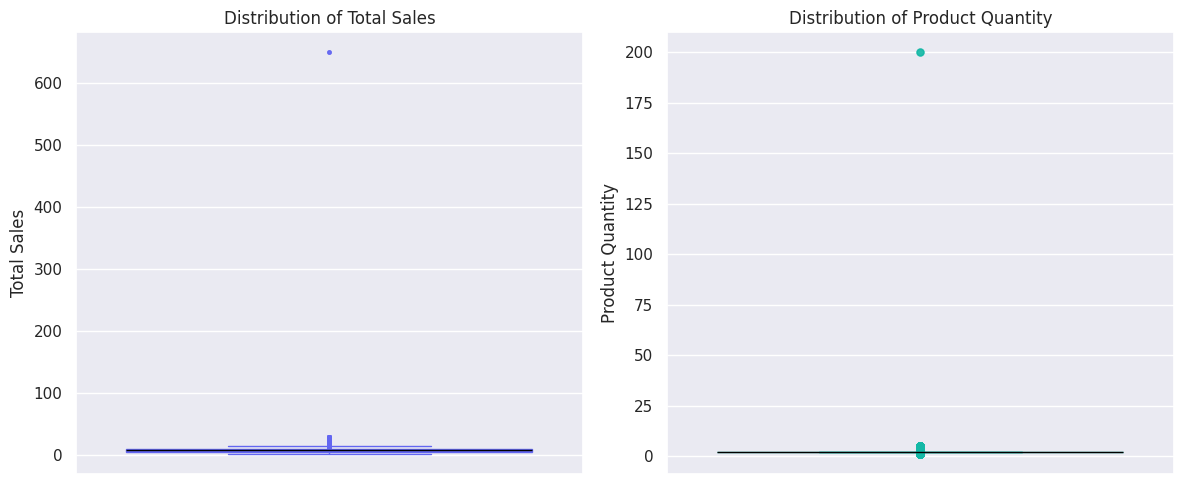

In [18]:
# Custom color palette
custom_palette = ["#6366F1", "#14B8A6"]

# Checking outliers in Total Sales and Product Quantity
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Total Sales
sns.boxplot(
    y=trans_data['TOT_SALES'],
    ax=axes[0],
    color=custom_palette[0],
    boxprops=dict(facecolor=custom_palette[0], edgecolor=custom_palette[0]),
    whiskerprops=dict(color=custom_palette[0]),
    capprops=dict(color=custom_palette[0]),
    medianprops=dict(color='black'),
    flierprops=dict(
        marker='.',
        markerfacecolor=custom_palette[0],
        markeredgecolor=custom_palette[0],
        markersize=5,
        alpha=0.7
    )
)

axes[0].set_title('Distribution of Total Sales')
axes[0].set_ylabel('Total Sales')


# Product Quantity
sns.boxplot(
    y=trans_data['PROD_QTY'],
    ax=axes[1],
    color=custom_palette[1],
    boxprops=dict(facecolor=custom_palette[1], edgecolor=custom_palette[1]),
    whiskerprops=dict(color=custom_palette[1]),
    capprops=dict(color=custom_palette[1]),
    medianprops=dict(color='black'),
    flierprops=dict(
        marker='.',
        markerfacecolor=custom_palette[1],
        markeredgecolor=custom_palette[1],
        markersize=5,
        alpha=0.7
    )
)

axes[1].set_title('Distribution of Product Quantity')
axes[1].set_ylabel('Product Quantity')

plt.tight_layout()
plt.show()

In [19]:
# Checking for outliers
# Check outliers for TOT_SALES and PROD_QTY in trans_data

import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows = 1, cols = 2,
    subplot_titles = ('Distribution: Total Sales', 'Distribution: Product Quantity')
)

fig.add_trace(
    go.Box(
        y=trans_data['TOT_SALES'], name='Total Sales'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Box(
        y=trans_data['PROD_QTY'], name='Prod Qty'
    ),
    row=1, col=2
)
fig.show()

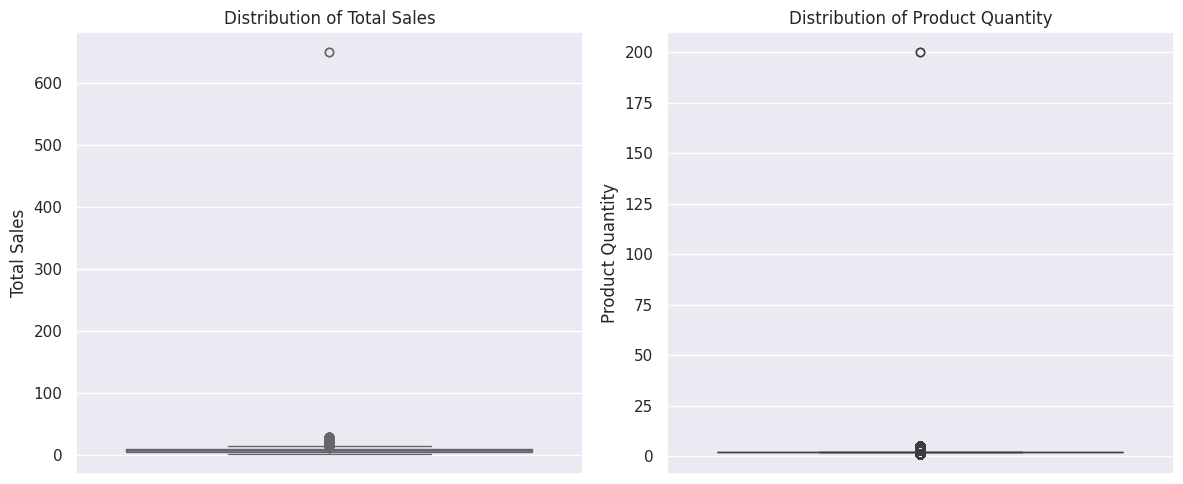

In [20]:
custom_palette = ["#6366F1", "#14B8A6"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Total Sales
sns.boxplot(
    y=trans_data['TOT_SALES'],
    ax=axes[0],
    color=custom_palette[0]
)
axes[0].set_title('Distribution of Total Sales')
axes[0].set_ylabel('Total Sales')

# Product Quantity
sns.boxplot(
    y=trans_data['PROD_QTY'],
    ax=axes[1],
    color=custom_palette[1]
)
axes[1].set_title('Distribution of Product Quantity')
axes[1].set_ylabel('Product Quantity')

plt.tight_layout()
plt.show()